# Trajectron++ – Model-Probability Tabanlı Rank

Bu notebook Trajectron++ distribution çıktılarından **GT gerektirmeden** predicted trajectory'leri rank eder:

1. **Log-Likelihood** – Her sample'ın GMM altındaki toplam log olasılığı (en yüksek = Rank #1)
2. **Most Likely (Z-mode)** – En yüksek π (mixture weight) olan modun trajectory'si
3. **Entropy** – Düşük entropy = daha güvenilir (opsiyonel)

In [30]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.home() / "Trajectron-plus-plus"
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "trajectron"))

print("Paths OK")

Paths OK


In [31]:
import dill
import json
import torch
import numpy as np
import matplotlib.pyplot as plt

from environment import Environment
from model.model_registrar import ModelRegistrar
from model.online.online_trajectron import OnlineTrajectron

In [32]:
# ========== AYARLAR ==========
PKL_PATH = PROJECT_ROOT / "experiments" / "processed" / "my_video_test.pkl"
MODEL_DIR = PROJECT_ROOT / "experiments" / "pedestrians" / "models" / "models_26_Dec_2025_14_50_24_eth_demo"
CHECKPOINT = 3
NUM_SAMPLES = 20

In [33]:
with open(PKL_PATH, "rb") as f:
    eval_env = dill.load(f)

with open(MODEL_DIR / "config.json", "r") as f:
    hyperparams = json.load(f)

hyperparams["incl_robot_node"] = False
hyperparams["offline_scene_graph"] = True

model_registrar = ModelRegistrar(MODEL_DIR, device="cpu")
model_registrar.load_models(iter_num=CHECKPOINT)

online_traj = OnlineTrajectron(model_registrar, hyperparams, device="cpu")
print("Model ready")


Loading from /Users/simayyalcin/Trajectron-plus-plus/experiments/pedestrians/models/models_26_Dec_2025_14_50_24_eth_demo/model_registrar-3.pt
Loaded!

Model ready


/Users/simayyalcin/Trajectron-plus-plus/trajectron/model/model_registrar.py:68: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model_dict = torch.load(save_path, map_loc

/Users/simayyalcin/Trajectron-plus-plus/trajectron/model/model_registrar.py:68: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model_dict = torch.load(save_path, map_loc

/Users/simayyalcin/Trajectron-plus-plus/trajectron/model/model_registrar.py:68: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model_dict = torch.load(save_path, map_loc

In [34]:
scene = eval_env.scenes[0]
max_hl = hyperparams["maximum_history_length"]
ph = hyperparams["prediction_horizon"]
latest_t = scene.timesteps - ph - 1
timestep = max_hl if max_hl <= latest_t else max(1, latest_t)

env = Environment(
    node_type_list=eval_env.node_type_list,
    standardization=eval_env.standardization,
    scenes=[scene],
    attention_radius=eval_env.attention_radius,
    robot_type=eval_env.robot_type
)

online_traj.set_environment(env, timestep)
input_dict = scene.get_clipped_input_dict(timestep, hyperparams["state"])

dists, preds = online_traj.incremental_forward(
    input_dict,
    maps=None,
    prediction_horizon=ph,
    num_samples=NUM_SAMPLES,
    full_dist=True
)

print("timestep:", timestep, "| nodes:", list(preds.keys()))

/Users/simayyalcin/miniconda3/envs/trajectron/lib/python3.8/site-packages/torch/distributions/distribution.py:55: UserWarning: <class 'model.components.gmm2d.GMM2D'> does not define `arg_constraints`. Please set `arg_constraints = {}` or initialize the distribution with `validate_args=False` to turn off validation.
  warnings.warn(


timestep: 7 | nodes: [PEDESTRIAN/0]


/Users/simayyalcin/miniconda3/envs/trajectron/lib/python3.8/site-packages/torch/distributions/distribution.py:55: UserWarning: <class 'model.components.gmm2d.GMM2D'> does not define `arg_constraints`. Please set `arg_constraints = {}` or initialize the distribution with `validate_args=False` to turn off validation.
  warnings.warn(


/Users/simayyalcin/miniconda3/envs/trajectron/lib/python3.8/site-packages/torch/distributions/distribution.py:55: UserWarning: <class 'model.components.gmm2d.GMM2D'> does not define `arg_constraints`. Please set `arg_constraints = {}` or initialize the distribution with `validate_args=False` to turn off validation.
  warnings.warn(


In [35]:
def rank_by_log_likelihood(dists, preds, device="cpu"):
    """Her sample için GMM altında toplam log-prob hesapla, rank et."""
    rankings = {}
    for node in preds:
        dist = dists[node]
        samples = preds[node]  # [1, num_samples, ph, 2]
        n_samples = samples.shape[1]
        log_probs = []
        for s in range(n_samples):
            traj = samples[0, s, :, :]  # [ph, 2]
            total_lp = 0.0
            try:
                for t in range(traj.shape[0]):
                    pt = torch.tensor(traj[t:t+1], dtype=torch.float32, device=device)
                    gmm_t = dist.get_for_node_at_time(0, t)
                    lp = gmm_t.log_prob(pt)
                    total_lp += lp.item()
            except Exception:
                total_lp = -np.inf
            log_probs.append(total_lp)
        order = np.argsort(log_probs)[::-1]
        rankings[node] = {"scores": np.array(log_probs), "order": order}
    return rankings


def get_most_likely_trajectory(dists):
    """GMM2D.mode() ile en olası trajectory — boyut uyumsuzluğundan kaçınır."""
    most_likely = {}
    for node in dists:
        dist = dists[node]
        try:
            mode_traj = dist.mode().cpu().numpy()
            traj = np.squeeze(mode_traj)
            most_likely[node] = traj.reshape(-1, 2) if traj.ndim == 1 else traj
        except Exception:
            mus = np.squeeze(dist.mus.cpu().numpy())
            most_likely[node] = mus.reshape(-1, 2) if mus.ndim != 2 else mus
    return most_likely


def rank_by_entropy(dists):
    """Düşük entropy = daha güvenilir (rank 1)."""
    from scipy.stats import entropy
    entropies = {}
    for node in dists:
        pis = dists[node].pis_cat_dist.probs.cpu().numpy()
        pis = np.squeeze(pis)
        if pis.ndim == 1:
            e = entropy(pis + 1e-10)
        else:
            e = np.mean([entropy(pis[..., t, :].flatten() + 1e-10) for t in range(pis.shape[-2])])
        entropies[node] = e
    return entropies

In [36]:
# Rank hesapla
rank_ll = rank_by_log_likelihood(dists, preds)
most_likely_traj = get_most_likely_trajectory(dists)
entropies = rank_by_entropy(dists)

for node in preds:
    r = rank_ll[node]
    print(f"{node}: LogLik rank1 sample={r['order'][0]}, score={r['scores'][r['order'][0]]:.2f}")
    print(f"      Entropy={entropies.get(node, 'N/A'):.4f}")

PEDESTRIAN/0: LogLik rank1 sample=19, score=-inf
      Entropy=5.8069


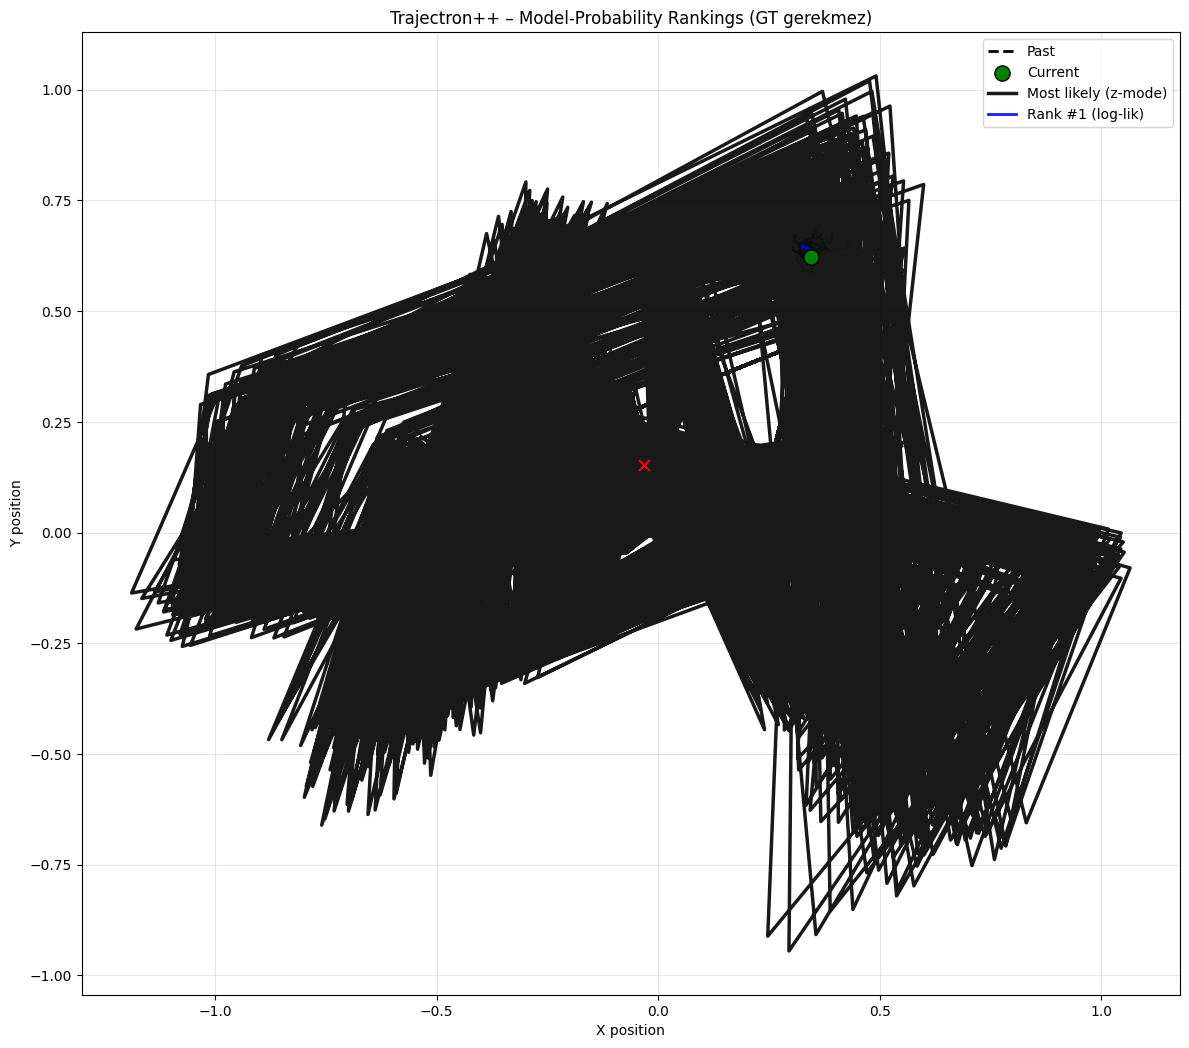

In [37]:
from matplotlib.lines import Line2D

def visualize_ranked_trajectories(scene, preds, dists, rank_ll, most_likely_traj, timestep, hyperparams):
    max_hl = hyperparams["maximum_history_length"]
    ph = hyperparams["prediction_horizon"]
    position_state = {"position": ["x", "y"]}
    
    fig, ax = plt.subplots(figsize=(12, 12))
    cmap = plt.cm.viridis
    
    for node in preds:
        history = node.get(np.array([timestep - max_hl, timestep]), position_state)
        history = history[~np.isnan(history.sum(axis=1))]
        if len(history) == 0:
            continue
        
        # Past
        ax.plot(history[:, 0], history[:, 1], 'k--', linewidth=2, label='Past' if node == list(preds.keys())[0] else None)
        
        # Current position
        ax.scatter(history[-1, 0], history[-1, 1], s=120, c='green', edgecolors='black', zorder=5, label='Current' if node == list(preds.keys())[0] else None)
        
        # Predicted samples (renk = rank)
        samples = preds[node][0]  # [num_samples, ph, 2]
        order = rank_ll[node]["order"]
        n = len(order)
        for i, idx in enumerate(order):
            alpha = 1.0 - 0.7 * (i / max(n, 1))
            color = cmap(i / max(n, 1))
            ax.plot(samples[idx, :, 0], samples[idx, :, 1], color=color, alpha=alpha, linewidth=1.5)
        
        # Most likely (z-mode) – kalın siyah kesikli
        ml = most_likely_traj[node]
        ax.plot(ml[:, 0], ml[:, 1], 'k-', linewidth=2.5, alpha=0.9, label='Most likely (z-mode)' if node == list(preds.keys())[0] else None)
        ax.scatter(ml[0, 0], ml[0, 1], s=60, c='red', marker='x', zorder=6)
        
        # Rank #1 (en yüksek log-lik) – mavi kalın
        r1_idx = order[0]
        ax.plot(samples[r1_idx, :, 0], samples[r1_idx, :, 1], 'b-', linewidth=2, alpha=0.9, label='Rank #1 (log-lik)' if node == list(preds.keys())[0] else None)
    
    ax.set_xlabel('X position')
    ax.set_ylabel('Y position')
    ax.set_title('Trajectron++ – Model-Probability Rankings (GT gerekmez)')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='box')
    plt.tight_layout()
    plt.show()


visualize_ranked_trajectories(scene, preds, dists, rank_ll, most_likely_traj, timestep, hyperparams)

In [38]:
# Rank özet tablosu
import pandas as pd

rows = []
for node in preds:
    r = rank_ll[node]
    for rank, idx in enumerate(r["order"], 1):
        rows.append({"node": str(node), "rank": rank, "sample_idx": idx, "log_likelihood": r["scores"][idx]})

df = pd.DataFrame(rows)
print(df.to_string(index=False))

        node  rank  sample_idx  log_likelihood
PEDESTRIAN/0     1          19            -inf
PEDESTRIAN/0     2          18            -inf
PEDESTRIAN/0     3           1            -inf
PEDESTRIAN/0     4           2            -inf
PEDESTRIAN/0     5           3            -inf
PEDESTRIAN/0     6           4            -inf
PEDESTRIAN/0     7           5            -inf
PEDESTRIAN/0     8           6            -inf
PEDESTRIAN/0     9           7            -inf
PEDESTRIAN/0    10           8            -inf
PEDESTRIAN/0    11           9            -inf
PEDESTRIAN/0    12          10            -inf
PEDESTRIAN/0    13          11            -inf
PEDESTRIAN/0    14          12            -inf
PEDESTRIAN/0    15          13            -inf
PEDESTRIAN/0    16          14            -inf
PEDESTRIAN/0    17          15            -inf
PEDESTRIAN/0    18          16            -inf
PEDESTRIAN/0    19          17            -inf
PEDESTRIAN/0    20           0            -inf
